In [1]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [3]:
#Load alerts file

df = pd.read_csv("data_gold/alerts_daily_combined.csv")

In [4]:
#Create Ground Truth

df["actual_anomaly"] = 0

df.loc[df["pct_change"] < -0.30, "actual_anomaly"] = 1
df.loc[df["pct_change"] > 0.30, "actual_anomaly"] = 1


In [5]:
#Predictions
y_true = df["actual_anomaly"]

y_rules = (df["method"] == "RULES").astype(int)
y_iforest = (df["method"] == "IFOREST").astype(int)

y_hybrid = ((y_rules + y_iforest) > 0).astype(int)


In [8]:
# Evaluation Function
def evaluate_model(name, y_true, y_pred):

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print(f"\n{name}")
    print("-" * 30)
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1 Score  : {f1:.3f}")

    cm = confusion_matrix(y_true, y_pred)

    return {
        "Method": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }

In [9]:
# Run Evaluation
results = []

results.append(
    evaluate_model(
        "Rule-Based",
        y_true,
        y_rules
    )
)

results.append(
    evaluate_model(
        "Isolation Forest",
        y_true,
        y_iforest
    )
)

results.append(
    evaluate_model(
        "Hybrid",
        y_true,
        y_hybrid
    )
)

results_df = pd.DataFrame([
    {
        "Method": r["Method"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1 Score": r["F1 Score"]
    }
    for r in results
])

print("\nSummary Results")
print(results_df)

results_df


Rule-Based
------------------------------
Precision : 0.435
Recall    : 1.000
F1 Score  : 0.607

Isolation Forest
------------------------------
Precision : 0.000
Recall    : 0.000
F1 Score  : 0.000

Hybrid
------------------------------
Precision : 0.431
Recall    : 1.000
F1 Score  : 0.602

Summary Results
             Method  Precision  Recall  F1 Score
0        Rule-Based   0.435245     1.0   0.60651
1  Isolation Forest   0.000000     0.0   0.00000
2            Hybrid   0.430861     1.0   0.60224


,Method,Precision,Recall,F1 Score
0,Rule-Based,0.435245,1.0,0.60651
1,Isolation Forest,0.000000,0.0,0.00000
2,Hybrid,0.430861,1.0,0.60224


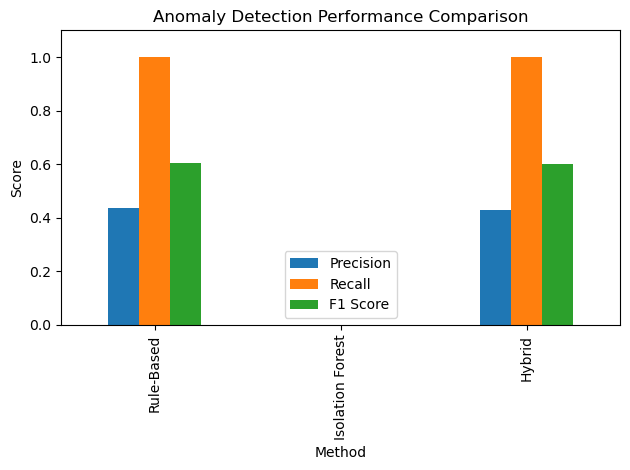

In [10]:
import matplotlib.pyplot as plt

results_df.set_index("Method")[
["Precision", "Recall", "F1 Score"]
].plot(kind="bar")

plt.title("Anomaly Detection Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

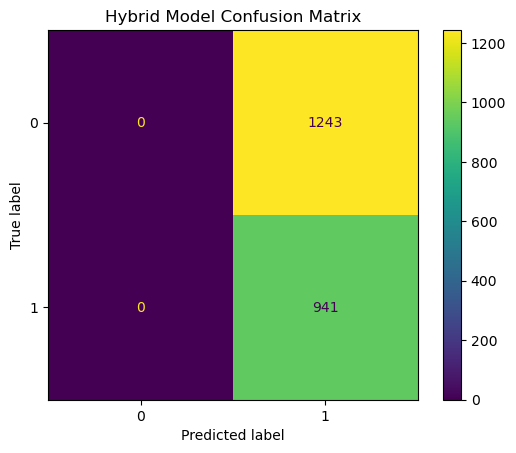

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_hybrid)

disp = ConfusionMatrixDisplay(
confusion_matrix=cm
)

disp.plot()

plt.title("Hybrid Model Confusion Matrix")
plt.show()